### Load Libraries

In [1]:
# Core
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.offsetbox import AnchoredText
from pathlib import Path
import matplotlib.patches as patches
from matplotlib.colors import Normalize
from matplotlib.gridspec import GridSpec
from matplotlib.ticker import LogLocator, LogFormatter
import re
import seaborn as sns
from matplotlib.ticker import FormatStrFormatter
from matplotlib.colors import to_rgba


# Stats
from statsmodels.nonparametric.smoothers_lowess import lowess
from statsmodels.genmod.families.links import Log
from statsmodels.genmod.generalized_linear_model import GLM
import statsmodels.formula.api as smf
import statsmodels.api as sm
from scipy.stats import binned_statistic
from scipy.optimize import curve_fit
from pygam import LinearGAM, s, f

### Colors

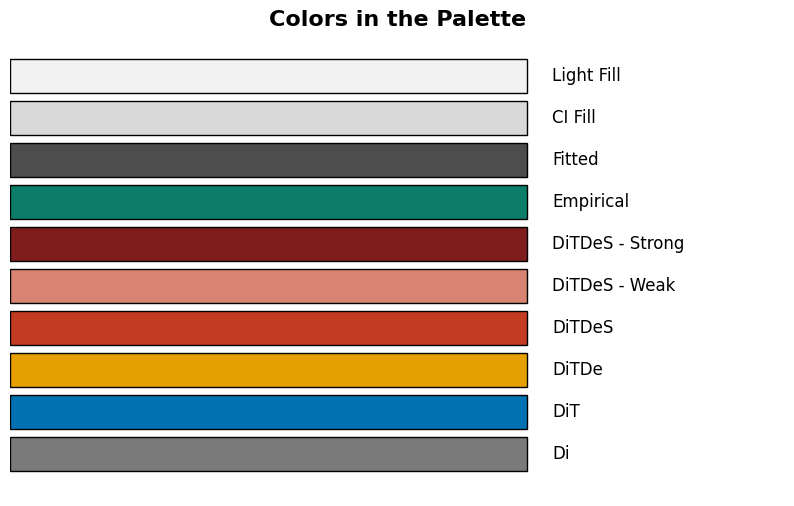

In [2]:
colors_figures_p2 = {

    # Core models (lightened slightly)
    "Di":               "#7A7F87",   # lighter storm gray
    "DiT":              "#3E6C8F",   # softened moor blue
    "DiTDe":            "#C18A47",   # lighter weathered ochre
    "DiTDeS - Strong":  "#7A1826",   # deep burgundy
    "DiTDeS":           "#A64242",   # claret red 
    "DiTDeS - Weak":    "#D79A9A",   # dusty rose


    # Data
    "Empirical":        "#3F5F5A",  # muted teal
    "Fitted":           "#4A4C50",  # softer graphite gray

    # Structure
    "CI Fill":          "#9AA3AD",  # light steel grey
    "Light Fill":       "#E6E2DB",  # light parchment
}

colors_figures_p2 = {
    # Core models
    "Di":               "#7A7A7A",   # neutral gray
    "DiT":              "#0072B2",   # CB-safe blue
    "DiTDe":            "#E69F00",   # CB-safe yellow/orange
    "DiTDeS":           "#C23B22",   # true red (not pink)


    # Intensity variants within red family
    "DiTDeS - Weak":     "#D88472",   # soft warm red
    "DiTDeS - Strong":   "#7F1D1D",   # dark deep red

    # Data / fit overlays
    "Empirical":        "#0B7D68",   # deeper teal (distinct from DiT blue)
    "Fitted":           "#4D4D4D",   # dark gray (not black)

    # Structural fills
    "CI Fill":          "#D9D9D9",   # light gray
    "Light Fill":       "#F2F2F2",   # very light gray
}






# ================================
# Create a bar chart to show the palette
# ================================

fig, ax = plt.subplots(figsize=(10, 6))

# Plot each color with its name
for i, (name, color) in enumerate(colors_figures_p2.items()):
    ax.barh(i, 1, color=color, edgecolor="black")
    ax.text(1.05, i, name, va='center', fontsize=12)

# Adjust the appearance of the plot
ax.set_xlim(0, 1.5)
ax.set_ylim(-1, len(colors_figures_p2))
ax.axis('off')
ax.set_title("Colors in the Palette", fontsize=16, weight='bold')

# Display the plot
plt.show()

### Global Style

In [3]:
POOLING_ORDER_RAW = ["sum", "mean", "max", "nearest"]
POOLING_TITLES    = ["Linear pooling (p)", "Averaging (a)", "Max (m)", "Nearest (n)"]
CORE_ORDER        = ["DiTDeS", "DiTDe", "DiT", "Di"]
CORE_COLORS = {
    "Di":    colors_figures_p2["Di"],  # baseline
    "DiT":   colors_figures_p2["DiT"],     # first addition
    "DiTDe": colors_figures_p2["DiTDe"],     # second addition
    "DiTDeS":colors_figures_p2["DiTDeS"],     # third addition
}

POOL_CODE = {"sum":"p", "max":"m", "nearest":"n", "mean":"a"}
CORE_CODE = {"DiT":"1", "DiTDe":"2", "DiTDeS":"3"}

INV_CORE_CODE = {v:k for k,v in CORE_CODE.items()}  # {"1":"Di", "2":"DiT", "3":"DiTDe", "4":"DiTDeS"}

# Readable names for the core pieces
CORE_NAME_TEXT = {
    "Di":    "Distance",
    "DiT":   "1 + Time",
    "DiTDe": "2 + Density",
    "DiTDeS":"3 + Speed",
}

In [4]:
# --- Normalizers ---------------------------------------------------------------
def _strip(s):
    return None if s is None else str(s).strip()

def core_display_label(core_key: str) -> str:
    """Return 'Model X — <name>' for canonical key; np.nan if bad."""
    if core_key not in CORE_CODE:
        return np.nan
    num  = CORE_CODE[core_key]
    name = CORE_NAME_TEXT[core_key]
    return f"Model {num} — {name}"

def normalize_pooling_raw(val):
    """
    Accepts raw pooling key or common variants; returns one of:
    'sum' | 'mean' | 'max' | 'nearest' or np.nan.
    """
    s = _strip(val)
    if not s:
        return np.nan
    s_low = s.lower()
    # direct hits
    if s_low in POOLING_ORDER_RAW:
        return s_low
    # tolerant aliases
    alias = {
        "linear": "sum",
        "linear pooling": "sum",
        "p": "sum",
        "a": "mean",
        "avg": "mean",
        "mean pooling": "mean",
        "maximum": "max",
        "m": "max",
        "nearest neighbor": "nearest",
        "n": "nearest",
    }
    return alias.get(s_low, np.nan)

def pooling_display_label(raw):
    """Return a consistent title like 'Linear pooling (p)'; np.nan-safe."""
    if raw is np.nan or raw is None:
        return np.nan
    r = normalize_pooling_raw(raw)
    if r is np.nan or r is None:
        return np.nan
    title_map = {k:v for k,v in zip(POOLING_ORDER_RAW, POOLING_TITLES)}
    title = title_map.get(r, r)
    code  = POOL_CODE.get(r, "")
    if code and not str(title).strip().endswith(f"({code})"):
        title = f"{title.split('(')[0].strip()} ({code})"
    return title

In [5]:
def show_grayscale(fig):
    # Draw the figure
    fig.canvas.draw()

    # Get RGBA buffer directly
    img = np.asarray(fig.canvas.buffer_rgba())

    # Convert RGBA → RGB
    rgb = img[..., :3]

    # Convert to grayscale using luminance formula
    gray = np.dot(rgb, [0.299, 0.587, 0.114])

    # Show grayscale version
    plt.figure(figsize=fig.get_size_inches())
    plt.imshow(gray, cmap='gray')
    plt.axis('off')
    plt.title("Grayscale version")
    plt.show()


In [6]:
def set_p2_style(base_fontsize=11):
    mpl.rcParams.update({
        # fonts & sizes
        "font.family": "sans-serif",
        "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],  # fallback to a common sans-serif font
        "font.size": base_fontsize,
        "axes.titlesize": base_fontsize + 1,
        "axes.labelsize": base_fontsize - 1,
        "xtick.labelsize": base_fontsize - 1,
        "ytick.labelsize": base_fontsize - 1,
        "mathtext.default": "regular",  # use regular font for mathtext
        "mathtext.fontset": "custom",
        "mathtext.rm": "Arial",
        "mathtext.it": "Arial:italic",
        "mathtext.bf": "Arial:bold",

        # lines/markers
        "lines.linewidth": 2.0,
        "lines.markersize": 5,
        "axes.linewidth": 1.0,

        # axes & grid
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.linewidth": 1.0,
        "axes.grid": False,
        "axes.grid.axis": "y",
        "grid.linestyle": "-",
        "grid.alpha": 0.12,
        
        # colors
        "axes.facecolor": "white",
        "figure.facecolor": "white",
        "savefig.facecolor": "white",


        # legend
        "legend.frameon": True,
        "legend.framealpha": 0.95,
        "legend.facecolor": "white",
        "legend.edgecolor": "#dddddd",
        "legend.fontsize": base_fontsize - 2,
        "legend.borderpad": 0.3,
        "legend.labelspacing": 0.3,
        "legend.handletextpad": 0.4,
    })


In [7]:
def add_panel_letters(fig, axes, letters=None, size=12, dx=0.01, dy=0.02):
    flat = axes.flat if hasattr(axes, "flat") else [axes]
    if letters is None:
        letters = [chr(ord('A') + i) for i in range(len(list(flat)))]
    for ax, L in zip(flat, letters):
        at = AnchoredText(L, prop=dict(weight="bold", size=size),
                          frameon=False, loc="upper left", pad=0.0,
                          bbox_to_anchor=(dx, 1 - dy), bbox_transform=ax.transAxes)
        ax.add_artist(at)

In [8]:
### - Shared constants for figure styling

FIG_WIDTH = 7.2  
FIG_LEFT = 0.11
FIG_RIGHT = 0.98
FIG_BOTTOM = 0.12
FIG_TOP = 0.94

LABEL_X = -0.10
LABEL_Y = 1.04
VA = "top"
HA = "left"

S_SCAT = 32
S_TRI = 40
LW_FIT = 2.3
ALPHA = 0.45
ALPHA_WEAK = 0.5
ALPHA_INT = 0.7
ALPHA_STRONG = 0.8

ALPHA_FILL = 0.09

### Datasets / Paths

In [9]:
from pathlib import Path
path = Path('..')


In [10]:
INFORMATION_PATH = path / 'data'
RESULTS_PATH     = path / 'outputs'
SIMULATION_PATH  = RESULTS_PATH / 'simulations' / 'GMM_3D'
SAVE_PATH        = path / 'outputs' / 'figures'
SAVE_PATH.mkdir(parents=True, exist_ok=True)


In [11]:

SR_INPUTDATA = pd.read_csv(INFORMATION_PATH / 'derived' / 'model_input.csv')

MODEL_FILE = pd.read_csv(RESULTS_PATH / 'model_fitting' / 'model_comparisons.csv')

GMM_LOGNORMAL = pd.read_csv(SIMULATION_PATH / 'Experimental_Simulations_3D_GMM_Results_20260224-113440_NFR1_FRspdlognormal_dec0p0551_tmax400.csv')
GMM_BINARY = pd.read_csv(SIMULATION_PATH / 'Experimental_Simulations_3D_GMM_Results_20260224-113618_NFR1_FRspdbinary_dec0p0551_tmax400.csv')

REAL_FILE = pd.read_csv(INFORMATION_PATH / 'derived' / 'response_videos.csv')
SUMMARIES = pd.read_csv(INFORMATION_PATH / 'all_observations.csv')

GMM_INPUTS_SUMMARY = pd.read_csv(SIMULATION_PATH / 'Diagnostics/TRACEINPUTS_20260302-151010_DiTDeS_NFR1_gmm_dec0.0551/SUMMARY_ALL.csv')
GMM_INPUTS_TRACE = pd.read_csv(SIMULATION_PATH / 'Diagnostics/TRACEINPUTS_20260302-151010_DiTDeS_NFR1_gmm_dec0.0551/TRACE_ALL.csv')
GMM_INPUTS_CONTRIBUTION = pd.read_csv(SIMULATION_PATH / 'Diagnostics/TRACEINPUTS_20260302-151010_DiTDeS_NFR1_gmm_dec0.0551/CONTRIB_TOPK_ALL.csv')
GMM_Rt = pd.read_csv(SIMULATION_PATH / 'Diagnostics/TRACEINPUTS_20260302-151010_DiTDeS_NFR1_gmm_dec0.0551/Rt_long.csv')

NSD_BINARY = pd.read_csv(SIMULATION_PATH / 'Experimental_Simulations_3D_GMM_Results_20260217-145633_NFR1_FRspdbinary_dec0p0000_tmax400.csv')
NSD_INPUTS_SUMMARY = pd.read_csv(SIMULATION_PATH / 'Diagnostics/TRACEINPUTS_20260302-154039_DiTDeS_NFR1_gmm_dec0/SUMMARY_ALL.csv')
NSD_INPUTS_TRACE = pd.read_csv(SIMULATION_PATH / 'Diagnostics/TRACEINPUTS_20260302-154039_DiTDeS_NFR1_gmm_dec0/TRACE_ALL.csv')
NSD_INPUTS_CONTRIBUTION = pd.read_csv(SIMULATION_PATH / 'Diagnostics/TRACEINPUTS_20260302-154039_DiTDeS_NFR1_gmm_dec0/CONTRIB_TOPK_ALL.csv')
NSD_Rt = pd.read_csv(SIMULATION_PATH / 'Diagnostics/TRACEINPUTS_20260302-154039_DiTDeS_NFR1_gmm_dec0/Rt_long.csv')

## General code

In [12]:
def add_panel_label(ax, label, fontsize=12):
    ax.annotate(
        label,
        xy=(0, 1), xycoords="axes fraction",
        xytext=(-11, 0), textcoords="offset points",  # fixed physical offset
        ha="right", va="bottom",
        fontsize=fontsize, fontweight="bold",
        annotation_clip=False
    )


## Figure 1 - Empirical Paradox

In [13]:
### - Setup needed columns for figure 1

REAL_FILE['Nr_Resp_NonFR'] = REAL_FILE['Cascade_Size'] - (REAL_FILE['Nr_FR'] + REAL_FILE['Nr_FRTC'])
REAL_FILE['Fraction_Resp_NonFR'] = REAL_FILE['Nr_Resp_NonFR'] / (REAL_FILE['Group_Size'] - (REAL_FILE['Nr_FR'] + REAL_FILE['Nr_FRTC']))
REAL_FILE["FR_MaxSpeed_mps"] = REAL_FILE["FR_MaxSpeed"] / 1000.0
REAL_FILE["Median_NND_m"] = REAL_FILE["Median_NND"] / 1000.0

In [14]:
### - Helper: add linear trend with confidence interval

def _add_linear_trend(ax, x, y, color='k', alpha_line=0.9, alpha_fill=0.15):
    # drop NA
    mask = np.isfinite(x) & np.isfinite(y)
    x = np.asarray(x)[mask]
    y = np.asarray(y)[mask]

    # design matrix
    X = sm.add_constant(x)
    model = sm.OLS(y, X).fit()

    # prediction grid
    x_pred = np.linspace(x.min(), x.max(), 200)
    X_pred = sm.add_constant(x_pred)
    pred = model.get_prediction(X_pred)
    ci = pred.conf_int()

    # plot
    ax.plot(x_pred, pred.predicted_mean, color=color, lw=LW_FIT)
    ax.fill_between(x_pred, ci[:, 0], ci[:, 1],
                    color=color, alpha=alpha_fill, linewidth=0)

### Fit OLS, SIGMOID, GAM

In [15]:
def fit_linear_ols(x, y):
    mask = np.isfinite(x) & np.isfinite(y)
    x = np.asarray(x)[mask]
    y = np.asarray(y)[mask]

    X = sm.add_constant(x)
    model = sm.OLS(y, X).fit()
    return model  

In [16]:
def logistic_3p(x, L, k, x0):
    return L / (1.0 + np.exp(-k * (x - x0)))

def fit_sigmoid_gaussian(x, y):
    mask = np.isfinite(x) & np.isfinite(y)
    x = np.asarray(x)[mask]
    y = np.asarray(y)[mask]

    # initial guesses
    L0  = np.clip(np.nanmax(y), 0.2, 1.2)
    x0  = np.nanmedian(x)
    # rough slope guess: avoid zero
    k0  = 5.0 / (np.nanstd(x) + 1e-9)

    p0 = (L0, k0, x0)

    # bounds keep it sane; tweak if needed
    bounds = ([0.0, 0.0, np.nanmin(x)], [1.2, 200.0, np.nanmax(x)])

    popt, pcov = curve_fit(logistic_3p, x, y, p0=p0, bounds=bounds, maxfev=10000)

    yhat = logistic_3p(x, *popt)
    resid = y - yhat
    sse = np.sum(resid**2)

    n = len(y)
    k = 3  # number of parameters
    sigma2_mle = sse / n
    ll = -0.5 * n * (np.log(2*np.pi*sigma2_mle) + 1.0)  # Gaussian log-likelihood at MLE sigma^2
    aic = 2*k - 2*ll
    bic = np.log(n)*k - 2*ll

    return {
        "params": {"L": popt[0], "k": popt[1], "x0": popt[2]},
        "pcov": pcov,
        "aic": aic,
        "bic": bic,
        "n": n,
        "sse": sse
    }

In [17]:
def fit_gam_spline(x, y, n_splines=10, lam=0.6):
    from pygam import LinearGAM, s

    mask = np.isfinite(x) & np.isfinite(y)
    x = np.asarray(x)[mask]
    y = np.asarray(y)[mask]

    X = x.reshape(-1, 1)

    gam = LinearGAM(s(0, n_splines=n_splines), lam=lam).fit(X, y)

    # pygam provides an AIC for Gaussian GAM
    aic = gam.statistics_["AIC"]
    bic = gam.statistics_["BIC"] if "BIC" in gam.statistics_ else np.nan

    return {"model": gam, "aic": aic, "bic": bic, "n": len(y)}

### Panel A - Cascade Fraction vs Group Size

In [18]:
def plot_1A(ax, df):
    df = df.copy()
    rng = np.random.default_rng(123)

    # Jitter for plotting ONLY
    df["Fraction_Resp_NonFR_plot"] = df["Fraction_Resp_NonFR"].astype(float)
    df["Fraction_Resp_NonFR_plot"] += rng.uniform(-0.02, 0.02, df.shape[0])

    # Scatter
    ax.scatter(df['Group_Size'], df['Fraction_Resp_NonFR_plot'],
               s=S_SCAT, alpha=ALPHA,
               color=colors_figures_p2['Empirical'],
               edgecolor='none')

    # Linear trend
    _add_linear_trend(ax,
                      df['Group_Size'].values,
                      df['Fraction_Resp_NonFR'].values,
                      color=colors_figures_p2['Fitted'],
                      alpha_fill=ALPHA_FILL)

    # Formatting
    ax.set_ylabel('Fraction recruited')
    ax.set_xlabel('Group size')
    ax.set_ylim(-0.1, 1.1)

    ax.set_yticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
    ax.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

### Panel B - Median NND vs Group Size

In [19]:
def plot_1B(ax, df):
    df = df.copy()
    # Scatter
    ax.scatter(df['Group_Size'], df['Median_NND_m'],
               s=S_SCAT, alpha=ALPHA,
               color=colors_figures_p2['Empirical'],
               edgecolor='none')

    # Linear trend
    _add_linear_trend(ax,
                      df['Group_Size'].values,
                      df['Median_NND_m'].values,
                      color=colors_figures_p2['Fitted'],
                      alpha_fill=ALPHA_FILL)

    # Formatting
    ax.set_ylabel('Median NND (m)')
    ax.set_xlabel('Group size')
    ax.set_ylim(0, 0.75)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

### Panel C - Cascade Size vs Max Initiator Speed

In [20]:
def compare_linear_sigmoid_gam(x, y):
    # Linear
    m_lin = fit_linear_ols(x, y)
    out = {
        "linear": {"aic": m_lin.aic, "bic": m_lin.bic, "n": int(m_lin.nobs), "model": m_lin},
    }

    # Sigmoid
    try:
        out["sigmoid"] = fit_sigmoid_gaussian(x, y)
    except Exception as e:
        out["sigmoid"] = {"error": str(e)}

    # GAM spline
    try:
        out["gam"] = fit_gam_spline(x, y)
    except Exception as e:
        out["gam"] = {"error": str(e)}

    return out

In [21]:
res = compare_linear_sigmoid_gam(REAL_FILE["FR_MaxSpeed_mps"], REAL_FILE["Fraction_Resp_NonFR"])

for k, v in res.items():
    if "error" in v:
        print(k, "FAILED:", v["error"])
    else:
        print(k, "AIC:", round(v["aic"], 2))

linear AIC: 35.86
sigmoid AIC: 37.74
gam AIC: 42.98


In [22]:
def plot_1C(ax, df):
    df = df.copy()
    rng = np.random.default_rng(123)
    
    # Jitter zeros for plotting ONLY
    df["Fraction_Resp_NonFR_plot"] = df["Fraction_Resp_NonFR"].astype(float)
    mask_zero = df["Fraction_Resp_NonFR_plot"] == 0
    df.loc[mask_zero, "Fraction_Resp_NonFR_plot"] += rng.uniform(-0.02, 0.02, mask_zero.sum())

    # Split by number of initiators
    df_single = df[df["Nr_FR"] == 1]
    df_multi  = df[df["Nr_FR"] > 1]

    # Scatter: single initiator
    ax.scatter(
        df_single["FR_MaxSpeed_mps"],
        df_single["Fraction_Resp_NonFR_plot"],
        s=S_SCAT, alpha=ALPHA,
        color=colors_figures_p2["Empirical"],
        marker="o",
        edgecolor="none"
    )

    # Scatter: multiple initiators
    ax.scatter(
        df_multi["FR_MaxSpeed_mps"],
        df_multi["Fraction_Resp_NonFR_plot"],
        s=S_TRI, alpha=ALPHA,
        color=colors_figures_p2["Empirical"],
        marker="^",
        edgecolor="none"
    )

    # Fit line on TRUE values (no jitter)
    _add_linear_trend(
        ax,
        df["FR_MaxSpeed_mps"].values,
        df["Fraction_Resp_NonFR"].values,
        color=colors_figures_p2["Fitted"],
        alpha_fill=ALPHA_FILL
    )

    # Formatting
    ax.set_ylabel("Fraction recruited")
    ax.set_xlabel("Maximum initiator speed (m/s)")
    ax.set_ylim(-0.1, 1.1)

    ax.set_yticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
    ax.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

### Panel D - Constraint in large groups

In [23]:
def plot_1D(ax, df,
    n_thresh=15,
    frac_thresh=0.40,
    speed_col="FR_MaxSpeed_mps",
    n_col="Group_Size",
    frac_col="Fraction_Resp_NonFR",
    nfr_col="Nr_FR",
    q_weak=0.25,
    q_strong=0.75,
    shade_gate=True,
    xMax=40,
    yMax=1
    ):

    df = df.copy()

    weak_thr   = df[speed_col].quantile(q_weak)
    strong_thr = df[speed_col].quantile(q_strong)

    print(f"Using speed thresholds: weak ≤ {weak_thr:.3f} m/s, strong ≥ {strong_thr:.3f} m/s")

    is_weak   = df[speed_col] <= weak_thr
    is_strong = df[speed_col] >= strong_thr
    is_mid    = ~(is_weak | is_strong)

    # -----------------------------
    # JITTER (safe + reproducible)
    # -----------------------------
    rng = np.random.default_rng(123)   # fixed seed for reproducibility

    # x jitter (group sizes are integers → lots of overlap)
    df["x_plot"] = df[n_col].astype(float) + rng.uniform(-0.5, 0.5, size=len(df))

    # y jitter: ONLY for exact zeros (stacked baseline)
    df["y_plot"] = df[frac_col].astype(float)
    mask0 = df["y_plot"] == 0
    df.loc[mask0, "y_plot"] += rng.uniform(0.0, 0.1, size=mask0.sum())

    # (optional) if you also have many exact 1.0 points, uncomment:
    # mask1 = df["y_plot"] == 1
    # df.loc[mask1, "y_plot"] -= rng.uniform(0.0, 0.02, size=mask1.sum())


    # --- graded claret colors (same hue axis) ---
    weak_color   = colors_figures_p2["DiTDeS - Weak"]    
    mid_color    = colors_figures_p2["DiTDeS"]           
    strong_color = colors_figures_p2["DiTDeS - Strong"]  

    # --- gate shading (make it a whisper) ---
    if shade_gate:
        x0 = n_thresh
        x1 = xMax
        y0 = frac_thresh
        y1 = yMax + 0.05

        rect = patches.Rectangle(
            (x0, y0),
            width=(x1 - x0),
            height=(y1 - y0),
            facecolor=colors_figures_p2["Light Fill"],
            alpha=ALPHA_FILL,
            edgecolor="none",
            zorder=0
        )
        ax.add_patch(rect)

    # Helper: plot subset with marker by Nr_FR, with adjustable alpha/size
    def _scatter_by_nfr(mask, color, alpha_o=ALPHA, alpha_t=ALPHA, s_o=S_SCAT, s_t=S_TRI, z=3, edgecolor="none"):
        df_sub = df.loc[mask]
        df_single = df_sub[df_sub[nfr_col] == 1]
        df_multi  = df_sub[df_sub[nfr_col] > 1]

        ax.scatter(df_single["x_plot"], df_single["y_plot"],
                   s=s_o, alpha=alpha_o, color=color,
                   marker="o", edgecolor=edgecolor, zorder=z)

        ax.scatter(df_multi["x_plot"], df_multi["y_plot"],
                   s=s_t, alpha=alpha_t, color=color,
                   marker="^", edgecolor=edgecolor, zorder=z+1)


    # --- plot mid first, then weak, then strong (so strong is on top) ---
    _scatter_by_nfr(is_mid,    mid_color,    alpha_o=ALPHA_INT, alpha_t=ALPHA_INT, s_o=S_SCAT, s_t=S_TRI, edgecolor="none", z=1)
    _scatter_by_nfr(is_weak,   weak_color,   alpha_o=ALPHA_WEAK, alpha_t=ALPHA_WEAK, s_o=S_SCAT, s_t=S_TRI, edgecolor="none", z=3)
    _scatter_by_nfr(is_strong, strong_color, alpha_o=ALPHA_STRONG, alpha_t=ALPHA_STRONG, s_o=S_SCAT, s_t=S_TRI, edgecolor="none", z=5)

    # --- threshold lines (slightly lighter/thinner) ---
    ax.vlines([n_thresh, n_thresh], ymin=-0.1, ymax=yMax + 0.05, color=colors_figures_p2["Fitted"], lw=1.0, ls="--", alpha=ALPHA, zorder=2)
    ax.hlines([frac_thresh, frac_thresh], xmin=0, xmax=xMax, color=colors_figures_p2["Fitted"], lw=1.0, ls="--", alpha=ALPHA, zorder=2)

    ax.set_xlabel("Group size")
    ax.set_ylabel("Fraction recruited")
    ax.set_ylim(-0.1, 1.1)
    ax.set_xlim(4, xMax + 1)

    ax.set_yticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
    ax.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


### Full Figure 1

In [24]:
def plot_Figure1(df):
    set_p2_style(base_fontsize=12)

    fig = plt.figure(figsize=(7.2, 5.6))
    gs = fig.add_gridspec(2, 2, wspace=0.22, hspace=0.28)
    fig.subplots_adjust(left=FIG_LEFT, right=FIG_RIGHT, top=FIG_TOP, bottom=FIG_BOTTOM + 0.08)

    axA = fig.add_subplot(gs[0, 0])
    axB = fig.add_subplot(gs[0, 1])
    axC = fig.add_subplot(gs[1, 0])
    axD = fig.add_subplot(gs[1, 1])

    plot_1A(axA, df)
    plot_1B(axB, df)   
    plot_1C(axC, df)
    plot_1D(axD, df)

    # -------------------------
    # GLOBAL LEGEND
    # -------------------------
    empirical = colors_figures_p2["Empirical"]
    strong_c  = colors_figures_p2["DiTDeS - Strong"]
    mid_c     = colors_figures_p2["DiTDeS"]   # your mid
    weak_c    = colors_figures_p2["DiTDeS - Weak"]   # your weak

    # Shapes: single vs multiple initiators
    shape_handles = [
        Line2D([0], [0], marker='o', linestyle='none',
               markerfacecolor=empirical, markeredgecolor='none',
               markersize=7, label='Single initiator'),
        Line2D([0], [0], marker='^', linestyle='none',
               markerfacecolor=empirical, markeredgecolor='none',
               markersize=8, label='Multiple initiators'),
    ]

    # Colors: weak / mid / strong (use circles so legend stays simple)
    color_handles = [
        Line2D([0], [0], marker='o', linestyle='none',
               markerfacecolor=weak_c, markeredgecolor='none',
               markersize=7, alpha=ALPHA_WEAK, label='Slow initiator'),
        Line2D([0], [0], marker='o', linestyle='none',
               markerfacecolor=mid_c, markeredgecolor='none',
               markersize=7, alpha=ALPHA_INT, label='Intermediate initiator'),
        Line2D([0], [0], marker='o', linestyle='none',
               markerfacecolor=strong_c, markeredgecolor='none',
               markersize=7, alpha=ALPHA_STRONG, label='Fast initiator'),
    ]

    handles = shape_handles + color_handles

    # Shape legend
    shape_legend = fig.legend(
        handles=shape_handles,
        loc="lower center",
        ncol=2,
        frameon=False,
        bbox_to_anchor=(0.5, 0.04)
    )

    # Color legend
    color_legend = fig.legend(
        handles=color_handles,
        loc="lower center",
        ncol=3,
        frameon=False,
        bbox_to_anchor=(0.5, 0.0)
    )

    # --- Add panel labels ---
    add_panel_label(axA, "A")
    add_panel_label(axB, "B")
    add_panel_label(axC, "C")
    add_panel_label(axD, "D")

    fig.savefig(SAVE_PATH / "Figure1.pdf", bbox_inches="tight")
    fig.savefig(SAVE_PATH / "Figure1.png", bbox_inches="tight", dpi=600)
    fig.savefig(SAVE_PATH / "Figure1.svg", bbox_inches="tight")

    return fig


Using speed thresholds: weak ≤ 0.947 m/s, strong ≥ 1.979 m/s


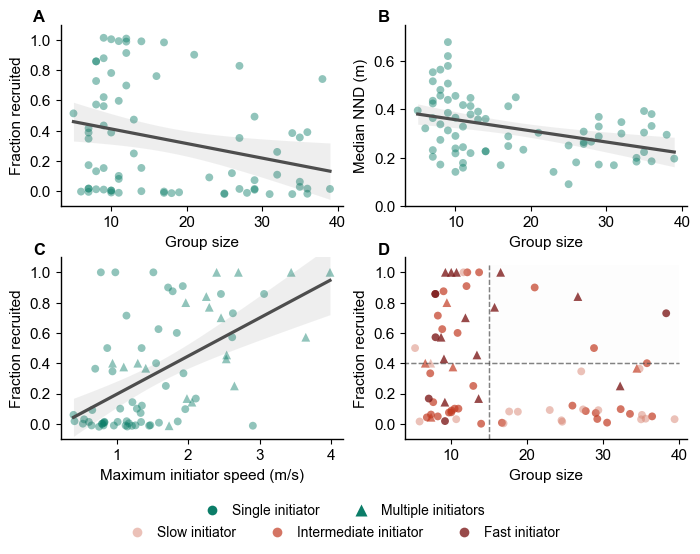

In [25]:
Fig1_2x2 = plot_Figure1(REAL_FILE)

## Figure 2 - Decision Rule

In [26]:
CORE_CODE = {"Di":"0", "DiT":"1", "DiTDe":"2", "DiTDeS":"3"}
POOL_CODE = {"sum":"p", "mean":"a", "max":"m", "nearest":"n"}

def _prep_df(df: pd.DataFrame) -> pd.DataFrame:
    """Validate + enforce categorical order used in plotting."""
    need = {"core", "pooling", "AIC"}
    if not need.issubset(df.columns):
        raise ValueError(f"Input needs columns {need}; got {df.columns.tolist()}")

    d = df.copy()
    d = d[d["core"].isin(CORE_ORDER) & d["pooling"].isin(POOLING_ORDER_RAW)].copy()
    d["core"]    = pd.Categorical(d["core"],    categories=CORE_ORDER,        ordered=True)
    d["pooling"] = pd.Categorical(d["pooling"], categories=POOLING_ORDER_RAW, ordered=True)
    return d

In [27]:
PARAMS_HAT = MODEL_FILE.loc[MODEL_FILE['AIC'] == MODEL_FILE['AIC'].min(), ['b0', 'b1', 'c']].iloc[0]

### Panel A - Comparison across all models

In [28]:
def plot_2A(ax, model_df):
    d = _prep_df(model_df).copy()

    # best pooling within each core structure
    best = (
        d.sort_values("AIC")
         .groupby("core", observed=False, as_index=False)
         .first()
    )
    best["core"] = pd.Categorical(best["core"], categories=CORE_ORDER, ordered=True)
    best = best.sort_values("core").reset_index(drop=True)

    best["Delta_AIC"] = best["AIC"] - best["AIC"].min()

    x = np.arange(len(best))
    cols = [CORE_COLORS[str(c)] for c in best["core"]]
    edgecolors = [to_rgba(CORE_COLORS[str(c)], alpha=0.4) for c in best["core"]]

    ax.grid(axis="y", alpha=0.06)

    ax.plot(x, best["Delta_AIC"], ls="--", lw=1.8, color=colors_figures_p2["Fitted"], alpha=0.7,
            marker="o", markerfacecolor="white", zorder=3)
    sizes = [85, 55, 55, 55]
    ax.scatter(x, best["Delta_AIC"], s=sizes, c=cols, edgecolors=edgecolors, linewidths=1, zorder=4)

    ax.set_xticks(x)
    ax.set_xticklabels(['(4) + Speed', '(3) + Density', '(2) + Time', '(1) Distance'], rotation=90)
    ax.set_ylabel(r"$\Delta$AIC")
    ax.set_xlabel("")

    ax.set_xlim(-0.6, 3.6)
    ax.set_ylim(-15, best["Delta_AIC"].max() * 1.15)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    return best

### Panel B - Predicted effect of distance x speed

In [29]:
def one_neighbor_effect(speed_mps, dist_m, ld, *, b0, b1, c):
    """
    Social contribution at t=0 for ONE neighbour (consistent with your R code family):
      D = (speed^c) * (1/dist^2)
      lambda = (1e-5 + b1*D) * exp(b0*LD)
    We return the social contribution (b1*D)*exp(b0*LD) (baseline omitted for clarity).
    """
    speed_mps = np.maximum(speed_mps, 0.0)
    dist_m    = np.maximum(dist_m, 1e-9)
    D = (speed_mps ** c) * (1.0 / (dist_m ** 2))
    return np.maximum((b1 * D) * np.exp(b0 * ld), 0.0)

In [30]:
def plot_2B(
    ax,
    df,
    *,
    b0_hat,
    b1_hat,
    c_hat,
    col_speed="Input_Speed",
    col_dist="Input_Distance",
    col_density="Focal_Local_Density",
    q=0.25,
    annotate=False,
):
    """
    Panel B: 2×2 bar plot (Close/Far × Slow/Fast),
    density fixed at mean.
    """

    d = df[[col_speed, col_dist, col_density]].dropna().copy()
    d["speed_mps"] = np.maximum(d[col_speed].astype(float).to_numpy() / 1000.0, 0.0)
    d["dist_m"]    = np.maximum(d[col_dist].astype(float).to_numpy() / 1000.0, 1e-9)
    d["ld"]        = d[col_density].astype(float).to_numpy()

    ld0 = float(np.mean(d["ld"]))

    dist_near = float(np.quantile(d["dist_m"], q))
    dist_far  = float(np.quantile(d["dist_m"], 1 - q))
    sp_slow   = float(np.quantile(d["speed_mps"], q))
    sp_fast   = float(np.quantile(d["speed_mps"], 1 - q))

    # compute predicted effects
    slow_vals = np.array([
        one_neighbor_effect(sp_slow, dist_near, ld0, b0=b0_hat, b1=b1_hat, c=c_hat),
        one_neighbor_effect(sp_slow, dist_far,  ld0, b0=b0_hat, b1=b1_hat, c=c_hat),
    ])

    fast_vals = np.array([
        one_neighbor_effect(sp_fast, dist_near, ld0, b0=b0_hat, b1=b1_hat, c=c_hat),
        one_neighbor_effect(sp_fast, dist_far,  ld0, b0=b0_hat, b1=b1_hat, c=c_hat),
    ])

    scale = 100.0  # convert to ×10^-2 units
    slow_vals_plot = slow_vals * scale
    fast_vals_plot = fast_vals * scale

    ax.cla()

    x = np.arange(2)  # Close, Far
    w = 0.45

    edgeweak = to_rgba(colors_figures_p2["DiTDeS - Weak"])
    edgestrong = to_rgba(colors_figures_p2["DiTDeS - Strong"], alpha=ALPHA)

    # Slow = lighter
    ax.bar(
        x - w/2,
        slow_vals_plot,
        width=w,
        label="Slow",
        color=colors_figures_p2["DiTDeS - Weak"],
        edgecolor=edgeweak, linewidth=1.5
    )

    # Fast = strong color
    ax.bar(
        x + w/2,
        fast_vals_plot,
        width=w,
        label="Fast",
        color=colors_figures_p2["DiTDeS - Strong"],
        edgecolor=edgestrong, linewidth=1.5
    )

    ax.set_xticks(x)
    ax.set_xticklabels(["Close", "Far"])
    ax.set_xlabel("Neighbor distance")
    ax.set_ylabel(r"Predicted social effect (a.u. $\times 10^{-2}$)")

    ymax = max(slow_vals_plot.max(), fast_vals_plot.max())
    ax.set_ylim(0, ymax * 1.15 if ymax > 0 else 1.0)

    handles = [
        Line2D([0], [0], color=colors_figures_p2["DiTDeS - Weak"], lw=0, marker='|', markersize=11,
            markeredgewidth=3.0, label="Slow"),
        Line2D([0], [0], color=colors_figures_p2["DiTDeS - Strong"], lw=0, marker='|', markersize=11,
            markeredgewidth=3.0, label="Fast"),
    ]

    ax.legend(handles=handles, frameon=False, loc="upper right",
            handlelength=0.7, handletextpad=0.6, borderaxespad=0.15)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

### Panel C - Pooling additivity

In [31]:
def compute_w(s_mps, d_m, c):
    s_mps = np.maximum(s_mps, 0.0)
    d_m   = np.maximum(d_m, 1e-9)
    return (s_mps ** c) * (1.0 / (d_m ** 2))

def pooled_C_for_prefix(s_mps, d_m, c, pooling):
    """Return pooled D for prefixes 1..N_max under a pooling rule."""
    w = compute_w(s_mps, d_m, c)

    if pooling == "sum":
        return np.cumsum(w)
    if pooling == "mean":
        return np.cumsum(w) / np.arange(1, len(w) + 1)
    if pooling == "max":
        return np.maximum.accumulate(w)
    if pooling == "nearest":
        out = np.zeros(len(w))
        best_j = 0
        best_d = d_m[0]
        out[0] = w[0]
        for i in range(1, len(w)):
            if d_m[i] < best_d:
                best_d = d_m[i]
                best_j = i
            out[i] = w[best_j]
        return out

    raise ValueError(f"Unknown pooling: {pooling}")

In [32]:
def plot_2C(
    ax,
    df,
    *,
    c_hat,
    col_speed="Input_Speed",   # mm/s
    col_dist="Input_Distance", # mm
    N_max=10,
    n_sets=200,
    seed=0,
    order="random",            # "random" or "strongest_first"
):
    """
    Panel C: pooling comparison at t=0.
    Samples (speed, distance) pairs from df and shows how pooled D grows with # responders.
    """
    d = df[[col_speed, col_dist]].dropna().copy()
    if d.empty:
        ax.set_axis_off()
        return

    s_all = np.maximum(d[col_speed].astype(float).to_numpy() / 1000.0, 0.0)   # m/s
    d_all = np.maximum(d[col_dist].astype(float).to_numpy() / 1000.0, 1e-9)  # m

    rng = np.random.default_rng(seed)

    poolings   = ["sum", "max", "nearest", "mean"]
    labels     = {"sum":"Linear (sum)", "max":"Max", "nearest":"Closest", "mean":"Mean"}
    colors     = {
        "sum": CORE_COLORS["DiTDeS"],
        "max": colors_figures_p2["Fitted"],
        "nearest": colors_figures_p2["Fitted"],
        "mean": colors_figures_p2["Fitted"],
    }
    linestyles = {"sum":"-", "max":"--", "nearest":"-.", "mean":":"}
    alphas     = {"sum": 1.0, "max": 0.85, "nearest": 0.8, "mean": 0.75}
    fill_alphas = {"sum": ALPHA_FILL, "max": 0.0, "nearest": 0.0, "mean": 0.0}

    curves = {p: [] for p in poolings}

    for _ in range(n_sets):
        idx = rng.choice(len(s_all), size=N_max, replace=True)
        sN = s_all[idx].copy()
        dN = d_all[idx].copy()

        if order == "strongest_first":
            wN = compute_w(sN, dN, c_hat)
            perm = np.argsort(-wN)
            sN, dN = sN[perm], dN[perm]
        elif order == "random":
            pass
        else:
            raise ValueError("order must be 'random' or 'strongest_first'")

        for p in poolings:
            curves[p].append(pooled_C_for_prefix(sN, dN, c_hat, p))

    stack = {p: np.vstack(curves[p]) for p in poolings}
    med   = {p: np.median(stack[p], axis=0) for p in poolings}
    lo    = {p: np.percentile(stack[p], 25.0, axis=0) for p in poolings}
    hi    = {p: np.percentile(stack[p], 75.0, axis=0) for p in poolings}

    x = np.arange(1, N_max + 1)

    for p in poolings:
        ax.plot(x, med[p], lw=LW_FIT if p == "sum" else 1.9,
                label=labels[p], color=colors[p], linestyle=linestyles[p], alpha=alphas[p])
        ax.fill_between(x, lo[p], hi[p], color=colors[p], alpha=fill_alphas[p], lw=0)

    # sensible ylim (avoid hard-coding)
    ymax = float(np.nanmax([med[p][-1] for p in poolings]))
    ax.set_ylim(0, ymax * 1.3)

    ax.set_xlabel("Number of responders")
    ax.set_ylabel("Pooled social input D (a.u.)")
    
    leg = ax.legend(frameon=True, framealpha=0.4, facecolor="white", edgecolor="none", loc="upper left")
    for txt, h in zip(leg.get_texts(), leg.legend_handles):
        if txt.get_text() == "Linear (sum)":
            h.set_linewidth(2.0)   # slightly thinner than plot (2.2)
        else:
            h.set_linewidth(1.5)   # thinner grey lines
            h.set_alpha(0.8)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

### Full Figure 2

In [33]:
def plot_Figure2(
    df_models: pd.DataFrame,
    df_inputdata: pd.DataFrame,
    *,
    params_hat,
    q_tradeoff=0.25,
):
    """
    Figure 2 (CB main text): one-row, three panels (A|B|C)

    A: best pooling per structure (ΔAIC)
    B: distance × speed trade-off (2×2 bars; q=0.25/0.75 by default)
    C: additivity across responders (pooling rules)
    """
    set_p2_style(base_fontsize=12)

    # accept Series or dict
    if hasattr(params_hat, "to_dict"):
        params_hat = params_hat.to_dict()

    # your PARAMS_HAT is b0,b1,c
    b0_hat = float(params_hat.get("b0", params_hat.get("b0_hat")))
    b1_hat = float(params_hat.get("b1", params_hat.get("b1_hat")))
    c_hat  = float(params_hat.get("c",  params_hat.get("c_hat")))

    fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(FIG_WIDTH, 3.1), gridspec_kw={"wspace": 0.5})
    fig.subplots_adjust(left=FIG_LEFT, right=FIG_RIGHT, top=FIG_TOP, bottom=FIG_BOTTOM)
    axA, axB, axC = axes

    # Panel A
    plot_2A(axA, df_models)

    # Panel B: trade-off bars (uses your existing function; keep q=0.25)
    plot_2B(axB, df_inputdata, b0_hat=b0_hat, b1_hat=b1_hat, c_hat=c_hat,
            col_speed="Input_Speed", col_dist="Input_Distance", col_density="Focal_Local_Density",
            q=q_tradeoff, annotate=False)

    # Panel C: pooling additivity (clean)
    plot_2C(axC, df_inputdata, c_hat=c_hat,
            col_speed="Input_Speed", col_dist="Input_Distance",
            N_max=10, n_sets=200, seed=0, order="random")

    # --- Add panel labels ---
    add_panel_label(axA, "A")
    add_panel_label(axB, "B")
    add_panel_label(axC, "C")

    fig.savefig(SAVE_PATH / "Figure2.pdf", bbox_inches="tight")
    fig.savefig(SAVE_PATH / "Figure2.png", bbox_inches="tight", dpi=600)
    fig.savefig(SAVE_PATH / "Figure2.svg", bbox_inches="tight")

    return fig

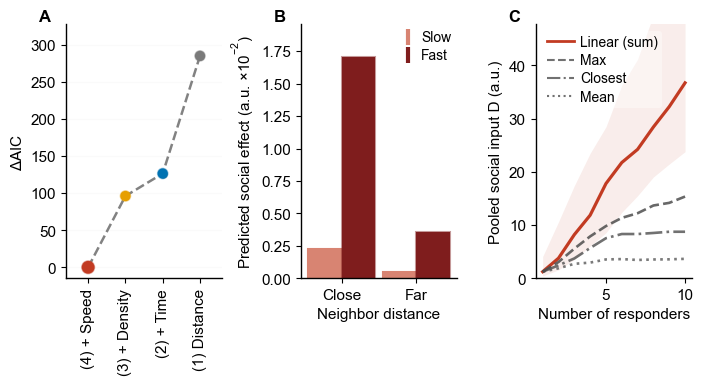

In [34]:
fig2 = plot_Figure2(MODEL_FILE, SR_INPUTDATA.loc[SR_INPUTDATA['Input_Speed'] > 0].copy(), params_hat=PARAMS_HAT)

## Figure 3 - Simulations

In [35]:
def _ensure_frac_recruited_sim(df):
    """Adds frac_recruited_excl_FR for simulation trials."""
    d = df.copy()
    add = d["N_Startles"] - d["N_FRs"]
    denom = (d["N_Fish"] - d["N_FRs"]).replace(0, np.nan)
    d["frac_recruited_excl_FR"] = add / denom
    return d

In [36]:
def summarize_iqr(df, group_cols, y):
    """Median + IQR summary (no smoothing)."""
    out = (
        df.dropna(subset=list(group_cols) + [y])
          .groupby(list(group_cols), dropna=False)[y]
          .agg(
              median="median",
              q25=lambda x: np.quantile(x, 0.25),
              q75=lambda x: np.quantile(x, 0.75),
          )
          .reset_index()
    )
    return out

In [37]:
def plot_line_iqr(ax, df, *, x="GroupSize",
                  y="median_smooth", ylo="q25_smooth", yhi="q75_smooth",
                  color="k", lw=LW_FIT, alpha_fill=0.10, ls="-", label=None, z=2):
    ax.plot(df[x], df[y], color=color, lw=lw, ls=ls, label=label, zorder=z)
    ax.fill_between(df[x], df[ylo], df[yhi], color=color, alpha=alpha_fill, lw=0, zorder=z-1)

In [38]:
def lowess_smooth_summary(summ, x, group_cols, frac=0.35):
    """
    Applies LOWESS to median, q25, q75 within each group.
    Returns same structure with *_smooth columns.
    """
    out = []

    for _, sub in summ.groupby(list(group_cols), dropna=False):
        sub = sub.sort_values(x).copy()

        for col in ["median", "q25", "q75"]:
            sm = lowess(
                sub[col],
                sub[x],
                frac=frac,
                return_sorted=False
            )
            sub[f"{col}_smooth"] = sm

        out.append(sub)

    return pd.concat(out, ignore_index=True)

### Panel A - Cascade size vs group size across model variants (Di, DiT, DiTDe, DiTDeS)

In [39]:
def prep_3A(REAL_FILE, GMM_LOGNORMAL, *, emp_frac=0.45, sim_frac=0.30):

    # ---- Empirical: raw -> summary -> lowess ----
    emp = REAL_FILE.dropna(subset=["Group_Size", "Fraction_Resp_NonFR"]).copy()
    emp_summ = summarize_iqr(
        emp.rename(columns={"Group_Size": "GroupSize"}),
        group_cols=("GroupSize",),
        y="Fraction_Resp_NonFR"
    )
    emp_summ["Model"] = "Empirical"
    emp_summ["Geometry"] = "Data"

    emp_sm = lowess_smooth_summary(
        emp_summ, x="GroupSize",
        group_cols=("Model", "Geometry"),
        frac=emp_frac
    )

    # ---- Sims: raw -> add frac -> summary -> lowess ----
    sims = _ensure_frac_recruited_sim(GMM_LOGNORMAL)
    sims = sims.dropna(subset=["Model", "N_Fish", "frac_recruited_excl_FR"]).copy()
    sims["Geometry"] = "GMM"

    sims_summ = summarize_iqr(
        sims.rename(columns={"N_Fish": "GroupSize"}),
        group_cols=("Model", "Geometry", "GroupSize"),
        y="frac_recruited_excl_FR"
    )

    sims_sm = lowess_smooth_summary(
        sims_summ, x="GroupSize",
        group_cols=("Model", "Geometry"),
        frac=sim_frac
    )

    return emp_sm, sims_sm

In [40]:
def plot_3A(
    axes, emp_sm, sims_sm,
    *, model_order=("Di", "DiT", "DiTDe", "DiTDeS"),
    xlim=(5, 37), ylim=(0, 1.10),
    model_colors=None,
    ylabel="Fraction recruited",
    basefontsize = 12
):
    model_colors = model_colors or CORE_COLORS

    for ax, model, model_name, lab in zip(axes, model_order, ["(1) Distance", "(2) 1 + Time", "(3) 2 + Density", "(4) 3 + Speed"], ["A", "B", "C", "D"]):

        # Data (smoothed)
        plot_line_iqr(
            ax, emp_sm, x="GroupSize",
            color=colors_figures_p2["Fitted"],
            lw=1.8, ls="--", alpha_fill=ALPHA_FILL * 0.7, z=2
        )

        # Simulation (smoothed)
        sub = sims_sm[(sims_sm["Model"].astype(str) == model) & (sims_sm["Geometry"] == "GMM")]
        if len(sub):
            plot_line_iqr(
                ax, sub, x="GroupSize",
                color=model_colors.get(model, "k"),
                lw=LW_FIT, alpha_fill=ALPHA_FILL * 0.7, z=3
            )

        #panel_label(ax, lab)
        ax.set_xlim(*xlim)
        ax.set_ylim(*ylim)
        ax.set_xlabel("Group size")
        ax.set_ylabel(ylabel)
        ax.text(0.04, 0.98, model_name, transform=ax.transAxes, va="top", ha="left", fontsize = basefontsize - 1,bbox=dict(boxstyle="round,pad=0.3", facecolor='white', edgecolor=colors_figures_p2[model], alpha=ALPHA))

    # Legend handles that match the plotted styles
    handles = [
        Line2D([0], [0], color=colors_figures_p2["Fitted"], lw=1.8, ls="--", label="Data"),
        Line2D([0], [0], color=colors_figures_p2.get("DiTDeS", "k"), lw=2.3, ls="-",  label="Simulation"),
    ]
    return handles

#### Full Figure 3

In [41]:
def plot_Figure3(
    REAL_FILE, GMM_LOGNORMAL,
    *, emp_frac=0.45, sim_frac=0.30,
    model_order=("Di", "DiT", "DiTDe", "DiTDeS"),
    xlim=(5, 37), ylim=(0, 1.10),
    figwidth=FIG_WIDTH, basefontsize=12,
):

    set_p2_style(base_fontsize=basefontsize)

    max_real_group = REAL_FILE["Group_Size"].max()

    emp_sm, sims_sm = prep_3A(
        REAL_FILE,
        GMM_LOGNORMAL[GMM_LOGNORMAL["N_Fish"] <= max_real_group].copy(),
        emp_frac=emp_frac,
        sim_frac=sim_frac
    )

    # ---- Create 2x2 layout only ----
    fig, axes = plt.subplots(
        2, 2,
        figsize=(figwidth, figwidth),
        sharex=True,
        sharey=True,
    )

    fig.subplots_adjust(
        left=FIG_LEFT,
        right=FIG_RIGHT,
        top=FIG_TOP,
        bottom=FIG_BOTTOM,
        wspace=0.12,
        hspace=0.12
    )

    axesA = axes.flatten()

    handles = plot_3A(
        axesA,
        emp_sm,
        sims_sm,
        model_order=model_order,
        xlim=xlim,
        ylim=ylim,
    )

    # Remove interior labels
    for ax in axesA:
        ax.set_xlabel("")
        ax.set_ylabel("")

    # Hide interior tick labels
    axes[0, 1].tick_params(labelleft=False)
    axes[1, 1].tick_params(labelleft=False)
    axes[0, 0].tick_params(labelbottom=False)
    axes[0, 1].tick_params(labelbottom=False)

    # ---- Shared axis labels ----
    left   = min(ax.get_position().x0 for ax in axesA)
    right  = max(ax.get_position().x1 for ax in axesA)
    bottom = min(ax.get_position().y0 for ax in axesA)
    top    = max(ax.get_position().y1 for ax in axesA)

    fig.text(
        (left + right) / 2,
        bottom - 0.04,
        "Group size",
        ha="center",
        va="top",
        fontsize=basefontsize - 1
    )

    fig.text(
        left - 0.05,
        (bottom + top) / 2,
        "Fraction recruited",
        ha="right",
        va="center",
        rotation=90,
        fontsize=basefontsize - 1
    )

    # One shared legend (place in top-right panel)
    axes[1, 1].legend(handles=handles, frameon=False, loc="upper right")

    # Add panel labels
    add_panel_label(axes[0, 0], "A")
    add_panel_label(axes[0, 1], "B")
    add_panel_label(axes[1, 0], "C")
    add_panel_label(axes[1, 1], "D")

    fig.savefig(SAVE_PATH / "Figure3.pdf", bbox_inches="tight")
    fig.savefig(SAVE_PATH / "Figure3.png", bbox_inches="tight", dpi=600)
    fig.savefig(SAVE_PATH / "Figure3.svg", bbox_inches="tight")

    return fig

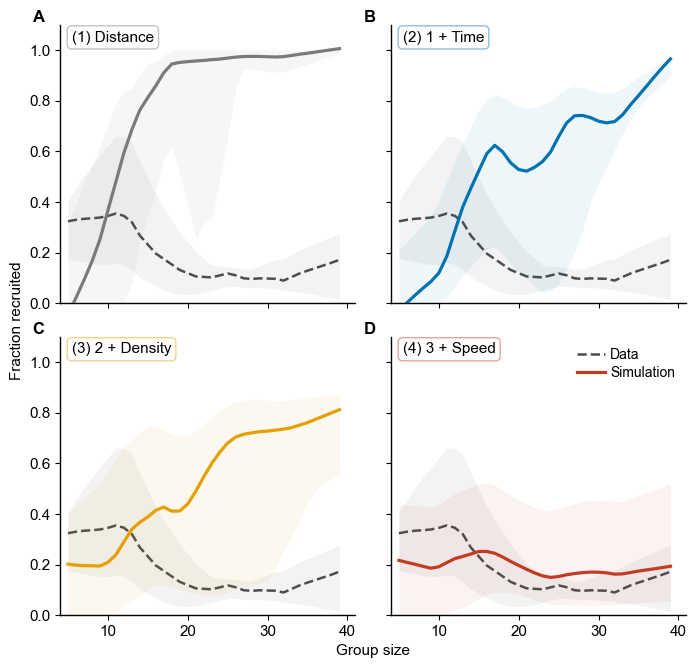

In [42]:
fig3 = plot_Figure3(
    REAL_FILE=REAL_FILE,
    GMM_LOGNORMAL=GMM_LOGNORMAL,
    emp_frac=0.45,
    sim_frac=0.30,
    xlim=(4, 41),
    basefontsize=12
)

## Figure 4 - Mechanism

### Panel A - Speed decay with time after initiator (EMPIRICAL DATA)

In [43]:
def exp_decay_i(t, i, a, lam):
    return i + a * np.exp(-lam * t)

In [44]:
def plot_4A(ax, df, x_col="After_FR", y_col="Speed",
            xlim=None, ylim=None, bin_width=5, basefontsize=12):

    df = df.loc[df['Response_Category'] == "SRNL"].copy()
    df['Speed_ms'] = df[y_col] / 1000.0
    df[x_col] = pd.to_numeric(df[x_col], errors="coerce")

    df = df[np.isfinite(df[x_col]) & np.isfinite(df['Speed_ms'])]

    # --- Try: fit exponential to raw data (not binned) ---
    popt, pcov = curve_fit(
        exp_decay_i,
        df[x_col],
        df["Speed_ms"],
        p0=(0.1, 0.5, 0.05),
        bounds=([0, 1e-6, 1e-6], [np.inf, np.inf, np.inf]),
        maxfev=20000
    )
    print("(RAW) Fitted parameters (i, a, lambda):", popt)

    # --- scatter ---
    ax.scatter(df[x_col], df["Speed_ms"],
               s=S_SCAT -5, alpha=ALPHA_WEAK - 0.3,
               color=colors_figures_p2['Empirical'],
               edgecolor="none", zorder=2)

    # --- BIN + MEDIAN ---
    df["bin"] = (df[x_col] // bin_width).astype(int)

    binned = (
        df.groupby("bin", as_index=False)
          .agg(t_med=(x_col, "median"),
               y_med=("Speed_ms", "median"),
               n=("bin", "size"))
    )

    # Optional: drop bins with very few points
    binned = binned[binned["n"] >= 3]

    t_med = binned["t_med"].values
    y_med = binned["y_med"].values

    # --- fit exponential to medians ---
    i0 = np.min(y_med)
    a0 = np.max(y_med) - i0
    lam0 = 0.05

    popt, pcov = curve_fit(
        exp_decay_i,
        t_med,
        y_med,
        p0=(i0, a0, lam0),
        bounds=([0, 1e-6, 1e-6], [np.inf, np.inf, np.inf]),
        maxfev=20000
    )

    i_hat, a_hat, lambda_hat = popt
    print(f"(MEDIAN, BINNED {bin_width}) Fitted parameters (i, a, lambda):", popt)

    # plot median points
    ax.scatter(t_med, y_med,
               s=S_SCAT, alpha=ALPHA_STRONG,
               color=colors_figures_p2["Fitted"],
               edgecolor=colors_figures_p2["Fitted"],
               zorder=4)

    # smooth line
    t_smooth = np.linspace(df[x_col].min(), df[x_col].max(), 300)
    v_fit = exp_decay_i(t_smooth, i_hat, a_hat, lambda_hat)

    ax.plot(t_smooth, v_fit,
            color=colors_figures_p2["Fitted"],
            lw=LW_FIT, ls="-", zorder=3)

    if xlim: ax.set_xlim(*xlim)
    if ylim: ax.set_ylim(*ylim)

    ax.set_xlabel("Time since initiator (frames)")
    ax.set_ylabel("Response speed (m/s)")

    ax.text(0.98, 0.97, f"$\\lambda$ = {lambda_hat:.4f} frame$^{{-1}}$",
        transform=ax.transAxes, ha="right", va="top", fontsize=basefontsize-1, color=colors_figures_p2["Fitted"])


    return ax, lambda_hat

### Panel B - Effect of slow and fast initiators (number)

In [46]:
def prep_4B(GMM_BINARY, *, model_name="DiTDeS", smooth_window=3):
    sims = _ensure_frac_recruited_sim(GMM_BINARY)
    sims["Nr_Resp_NonFR"] = sims["N_Startles"] - sims["N_FRs"]
    sims = sims.dropna(subset=["Model", "N_Fish", "Nr_Resp_NonFR", "FR_speed_label"]).copy()
    sims = sims[sims["Model"].astype(str) == model_name].copy()

    b = summarize_iqr(
        sims.rename(columns={"N_Fish": "GroupSize"}),
        group_cols=("FR_speed_label", "GroupSize"),
        y="Nr_Resp_NonFR"
    )
    b["Model"] = model_name
    b = b.sort_values(["FR_speed_label", "GroupSize"]).copy()

    # light smoothing: rolling median over neighboring group sizes
    for col in ["median", "q25", "q75"]:
        b[f"{col}_smooth"] = (
            b.groupby(["FR_speed_label", "Model"])[col]
             .transform(lambda s: s.rolling(window=smooth_window, center=True, min_periods=1).median())
        )

    return b


In [47]:
def plot_4B(
    ax, b_sm, real_file,
    *, xlim=(5, 37), ylim=(0, 40),
    colors=None,
    ylabel="Non-initiator responders (count)",
    label_letter="B",
    decay=True
):
    colors = colors or {
        "strong": colors_figures_p2["DiTDeS - Strong"],
        "weak":   colors_figures_p2["DiTDeS - Weak"],
    }

    ALPHA_FILLS = {
        "strong": ALPHA_FILL ,
        "weak":   ALPHA_FILL + 0.05,
    }

    NAMES = {
        "strong": "Fast initiators",
        "weak":   "Slow initiators",
    }

    # Only plot up to max real group size (avoid extrapolation)
    max_group_size = real_file["Group_Size"].max()
    b_sm = b_sm[b_sm["GroupSize"] <= max_group_size].copy()

    for lab in ["weak", "strong"]:
        sub = b_sm[b_sm["FR_speed_label"].astype(str) == lab]
        if len(sub):
            if decay:
                plot_line_iqr(ax, sub, x="GroupSize",
                          color=colors.get(lab, "k"),
                          lw=LW_FIT, alpha_fill=ALPHA_FILLS.get(lab, ALPHA_FILL),
                          label=NAMES.get(lab, lab.capitalize()),
                          z=3 if lab == "strong" else 2)
            if not decay:
                plot_line_iqr(ax, sub, x="GroupSize",
                          color=colors.get(lab, "k"),
                          lw=LW_FIT - 0.2, alpha_fill=0,
                          label=NAMES.get(lab, lab.capitalize()),
                          z=3 if lab == "strong" else 2,
                          ls="--")            
   

    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_xlabel("Group size")
    ax.set_ylabel(ylabel)
    


### Panel C - R(t) over time (2x2; slow/fast & small/large)

In [48]:
def _resolve_fr_levels(df, requested=("strong", "weak")):
    vals = [v for v in df["FR_label"].dropna().unique()]
    lower_map = {str(v).lower(): v for v in vals}
    out = []
    for r in requested:
        if str(r).lower() in lower_map:
            out.append(lower_map[str(r).lower()])
    if len(out) < 2 and len(vals) >= 2:
        out = vals[:2]
    return out

In [49]:
def prep_4C(rt_df, *, bin_width=5, smooth=3):
    d = rt_df.copy()
    d["time_bin"] = (pd.to_numeric(d["time"], errors="coerce") // bin_width) * bin_width

    rep_cols = ["Rep_ID", "FR_label", "N_req"]
    repbin = (
        d.groupby(rep_cols + ["time_bin"], as_index=False)
         .agg(R=("R", "mean"))
    )

    out = (
        repbin.groupby(["FR_label", "N_req", "time_bin"], as_index=False)
              .agg(
                  R_med=("R", "median"),
                  R_lo=("R", lambda x: np.quantile(x, 0.10)),
                  R_hi=("R", lambda x: np.quantile(x, 0.90)),
              )
              .sort_values(["FR_label", "N_req", "time_bin"])
    )

    if smooth > 1 and len(out):
        def _sm(g):
            g = g.sort_values("time_bin").copy()
            for col in ["R_med", "R_lo", "R_hi"]:
                g[col] = g[col].rolling(smooth, center=True, min_periods=1).median()
            return g
        out = out.sort_values(["FR_label", "N_req", "time_bin"]).copy()
        for col in ["R_med", "R_lo", "R_hi"]:
            out[col] = (
                out.groupby(["FR_label", "N_req"])[col]
                .transform(lambda s: s.rolling(smooth, center=True, min_periods=1).median())
            )


    return out

In [50]:
def plot_4C(axes, rt_df, *, fr_levels=("strong", "weak"), n_levels=(8, 30), xlim=(0, 50), bin_width=5, smooth=3, basefontsize=12, linestyle="-", decay=True):
    summ = prep_4C(rt_df, bin_width=bin_width, smooth=smooth)

    fr_use = _resolve_fr_levels(summ, requested=fr_levels)
    n_use = [int(n) for n in n_levels]

    sub = summ[summ["FR_label"].isin(fr_use) & pd.to_numeric(summ["N_req"], errors="coerce").isin(n_use)].copy()
    y_max = np.quantile(sub["R_hi"].dropna().to_numpy(), 0.95) * 1.1 if len(sub) else 2.0
    y_max = max(1.8, y_max)
    
    speed_dict = {"strong": "Fast", "weak": "Slow"}

    for r, fr in enumerate(fr_use):
        for c, nreq in enumerate(n_use):
            ax = axes[r, c]
            d = summ[(summ["FR_label"] == fr) & (pd.to_numeric(summ["N_req"], errors="coerce") == nreq)].copy()
            color = colors_figures_p2["DiTDeS - Strong"] if str(fr).lower() == "strong" else colors_figures_p2["DiTDeS - Weak"]

            if len(d):
                if decay:
                    ax.fill_between(d["time_bin"], d["R_lo"], d["R_hi"], color=color, alpha=ALPHA_FILL, lw=0, zorder=0)
                    ax.plot(d["time_bin"], d["R_med"], color=color, lw=LW_FIT, ls=linestyle, zorder=3)
                if not decay:
                    ax.plot(d["time_bin"], d["R_med"], color=color, lw=LW_FIT - 0.2, ls=linestyle, zorder=2)

            ax.axhline(1.0, ls="--", lw=1.3, color=colors_figures_p2["Fitted"], alpha=0.85)
            ax.set_xlim(*xlim)
            ax.set_ylim(0, y_max + 0.1)
            #ax.set_title(f"{str(fr).capitalize()}, N={nreq}", loc="left", fontsize=10)
            ax.grid(axis="y", alpha=0.10)

            if r < len(fr_use)-1:
                ax.tick_params(labelbottom=False)
            if c > 0:
                ax.tick_params(labelleft=False)

            # plot shaded area for initial response period (e.g., first 5 frames)
            ax.axvspan(0, 5, color=colors_figures_p2['CI Fill'], alpha=0.12, ec="none", zorder=1)
            ax.axvline(5, ls=":", lw=1, color=colors_figures_p2['CI Fill'], alpha=0.6, zorder=2)

            if r == 0:
                ax.set_title(f"N = {nreq}", loc="center", y=1.01)

    return axes

(RAW) Fitted parameters (i, a, lambda): [0.55423978 2.70333837 0.05908856]
(MEDIAN, BINNED 5) Fitted parameters (i, a, lambda): [0.38210241 2.81869645 0.05514106]


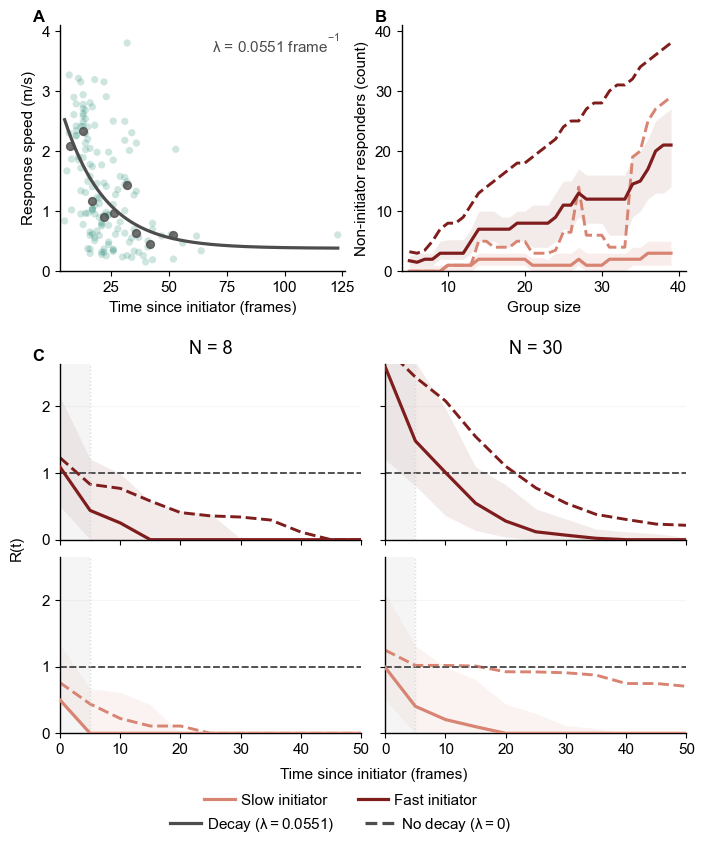

In [51]:
def plot_Figure4(
    *,
    summaries_df=SUMMARIES,
    gmm_binary_df=GMM_BINARY,
    NSD_binary_df=NSD_BINARY,
    rt_df=GMM_Rt,
    NSD_df = NSD_Rt,
    real_df=REAL_FILE if "REAL_FILE" in globals() else None,
    figwidth=FIG_WIDTH,
    xlim_c=(0, 50),
    save_prefix="Figure4",
    basefontsize=12,
):
    set_p2_style(base_fontsize=basefontsize)

    fig = plt.figure(figsize=(figwidth, figwidth * 1.2))
    fig.subplots_adjust(left=FIG_LEFT, right=FIG_RIGHT, top=FIG_TOP, bottom=FIG_BOTTOM)

    gs = fig.add_gridspec(2, 2, height_ratios=[0.9, 1.35], hspace=0.3, wspace=0.2)

    # Switched order: A is empirical, B is initiator effect
    axA = fig.add_subplot(gs[0, 0])
    axB = fig.add_subplot(gs[0, 1])

    plot_4A(axA, summaries_df, xlim=(3, 126), ylim=(0, 4.1), bin_width=5, basefontsize=basefontsize)
    #plot_4B(axB, prep_4B(gmm_binary_df, frac=0.35, model_name="DiTDeS")[1], real_file=real_df, xlim=(4, 41), ylim=(0, 41), decay=True)
    #plot_4B(axB, prep_4B(NSD_binary_df, frac=0.35, model_name="DiTDeS")[1], real_file=real_df, xlim=(4, 41), ylim=(0, 41), decay=False)

    plot_4B(axB, prep_4B(gmm_binary_df, model_name="DiTDeS", smooth_window=3), real_file=real_df, xlim=(4, 41), ylim=(0, 41), decay=True)
    plot_4B(axB, prep_4B(NSD_binary_df, model_name="DiTDeS", smooth_window=3), real_file=real_df, xlim=(4, 41), ylim=(0, 41), decay=False)


    # Panel C (R(t) only), 2x2
    cgrid = gs[1, :].subgridspec(2, 2, wspace=0.08, hspace=0.10)
    axesC = np.array([
        [fig.add_subplot(cgrid[0, 0]), fig.add_subplot(cgrid[0, 1])],
        [fig.add_subplot(cgrid[1, 0]), fig.add_subplot(cgrid[1, 1])],
    ])

    # positions for C block
    left   = min(ax.get_position().x0 for ax in axesC.flat)
    right  = max(ax.get_position().x1 for ax in axesC.flat)
    bottom = min(ax.get_position().y0 for ax in axesC.flat)
    top    = max(ax.get_position().y1 for ax in axesC.flat)

    plot_4C(axesC, rt_df, fr_levels=("strong", "weak"), n_levels=(8, 30), xlim=xlim_c, bin_width=5, smooth=3, basefontsize=basefontsize, linestyle="-", decay=True)
    plot_4C(axesC, NSD_df, fr_levels=("strong", "weak"), n_levels=(8, 30), xlim=xlim_c, bin_width=5, smooth=3, basefontsize=basefontsize, linestyle="--", decay=False)

    fig.text((left + right) / 2, bottom - 0.04, "Time since initiator (frames)", ha="center", va="top", fontsize=basefontsize - 1)
    fig.text(left - 0.05, (bottom + top) / 2, "R(t)", ha="right", va="center", rotation=90, fontsize= basefontsize - 1)

    add_panel_label(axA, "A")
    add_panel_label(axB, "B")
    add_panel_label(axesC[0, 0], "C")

    # Color legend: initiator type
    color_handles = [
        Line2D([0], [0], color=colors_figures_p2["DiTDeS - Weak"],   lw=LW_FIT, label="Slow initiator"),
        Line2D([0], [0], color=colors_figures_p2["DiTDeS - Strong"], lw=LW_FIT, label="Fast initiator"),
    ]

    # Style legend: decay condition
    style_handles = [
        Line2D([0], [0], color=colors_figures_p2["Fitted"], lw=LW_FIT, ls="-",  label=r"Decay ($\lambda=0.0551$)"),
        Line2D([0], [0], color=colors_figures_p2["Fitted"], lw=LW_FIT, ls="--", label=r"No decay ($\lambda=0$)"),
    ]

    # place two clean figure legends
    fig.legend(
        handles=color_handles,
        loc="lower center",
        ncol=2,
        frameon=False,
        bbox_to_anchor=(0.5, 0.02),
        fontsize=basefontsize-1
    )

    fig.legend(
        handles=style_handles,
        loc="lower center",
        ncol=2,
        frameon=False,
        bbox_to_anchor=(0.5, -0.01),
        fontsize=basefontsize-1
    )

    fig.savefig(SAVE_PATH / f"{save_prefix}.pdf", bbox_inches="tight")
    fig.savefig(SAVE_PATH / f"{save_prefix}.png", bbox_inches="tight", dpi=600)
    fig.savefig(SAVE_PATH / f"{save_prefix}.svg", bbox_inches="tight")

    return fig


fig = plot_Figure4()

## SI Figures

In [ ]:
# Load supplementary model comparison files
timedep_models = pd.read_csv(path / 'outputs' / 'model_fitting' / 'model_comparisons_time_dependent.csv')
static_models  = pd.read_csv(path / 'outputs' / 'model_fitting' / 'model_comparisons.csv')


### SI Figure — Static vs time-dependent neighbour distances

Shows that using distances measured at each neighbour's response frame (time-dependent) rather than at the first responder frame (static) does not change the model ranking. This justifies using static distances in the simulations.

In [ ]:
# Load model comparison files
static_models   = pd.read_csv(path / 'outputs' / 'model_fitting' / 'model_comparisons.csv')
timedep_models  = pd.read_csv(path / 'outputs' / 'model_fitting' / 'model_comparisons_time_dependent.csv')

def prep_comparison(df, label):
    df = df.copy()
    df["distance_type"] = label
    df["dAIC"] = df["AIC"] - df["AIC"].min()
    # Short label: core + pooling abbreviation
    pool_abbr = {"sum": "p", "mean": "a", "max": "m", "nearest": "n"}
    df["model_label"] = df["core"] + "_" + df["pooling"].map(pool_abbr).fillna(df["pooling"])
    return df

static_df  = prep_comparison(static_models,  "Static (at FR frame)")
timedep_df = prep_comparison(timedep_models, "Time-dependent")
combined   = pd.concat([static_df, timedep_df], ignore_index=True)

# ── Figure: ΔAIC comparison ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5), sharey=True)
fig.suptitle("Model comparison: static vs time-dependent neighbour distances", fontsize=12)

core_order = ["DiTDeS", "DiTDe", "DiTS", "DiT", "DiDeS", "DiS", "DiDe", "Di"]
pool_order = ["sum", "mean", "max", "nearest"]
colors     = {"sum": "#7A1826", "mean": "#3E6C8F", "max": "#C18A47", "nearest": "#7A7F87"}
markers    = {"sum": "o", "mean": "s", "max": "^", "nearest": "D"}

for ax, (label, df) in zip(axes, [("Static
(distance at FR frame)", static_df),
                                   ("Time-dependent
(distance at response frame)", timedep_df)]):
    for pool in pool_order:
        sub = df[df["pooling"] == pool].copy()
        # Order by core_order
        sub["core_rank"] = sub["core"].map({c: i for i, c in enumerate(core_order)})
        sub = sub.sort_values("core_rank")
        ax.scatter(sub["dAIC"], sub["core"], color=colors[pool],
                   marker=markers[pool], s=60, label=pool, zorder=3, alpha=0.85)

    ax.axvline(0, color="black", linewidth=0.8, linestyle="--", alpha=0.5)
    ax.set_xlabel("ΔAIC (lower = better)", fontsize=10)
    ax.set_title(label, fontsize=10)
    ax.grid(axis="x", alpha=0.3)
    ax.set_xlim(left=-2)

axes[0].set_ylabel("Model structure", fontsize=10)

# Legend (pooling types)
from matplotlib.lines import Line2D
legend_handles = [Line2D([0], [0], marker=markers[p], color=colors[p],
                         linestyle="None", markersize=7, label=p.capitalize())
                  for p in pool_order]
axes[1].legend(handles=legend_handles, title="Pooling", fontsize=9,
               title_fontsize=9, loc="center right")

plt.tight_layout()

save_path = SAVE_PATH / "SI_static_vs_timedependent_distances.pdf"
fig.savefig(save_path, dpi=300, bbox_inches="tight")
print(f"Saved → {save_path}")
plt.show()

# ── Print key comparison ─────────────────────────────────────────────────────
print("\nBest model (static):")
print(static_df.nsmallest(3, "AIC")[["model_label", "AIC", "dAIC", "tau", "b0", "b1", "c"]])

print("\nBest model (time-dependent):")
print(timedep_df.nsmallest(3, "AIC")[["model_label", "AIC", "dAIC", "tau", "b0", "b1", "c"]])


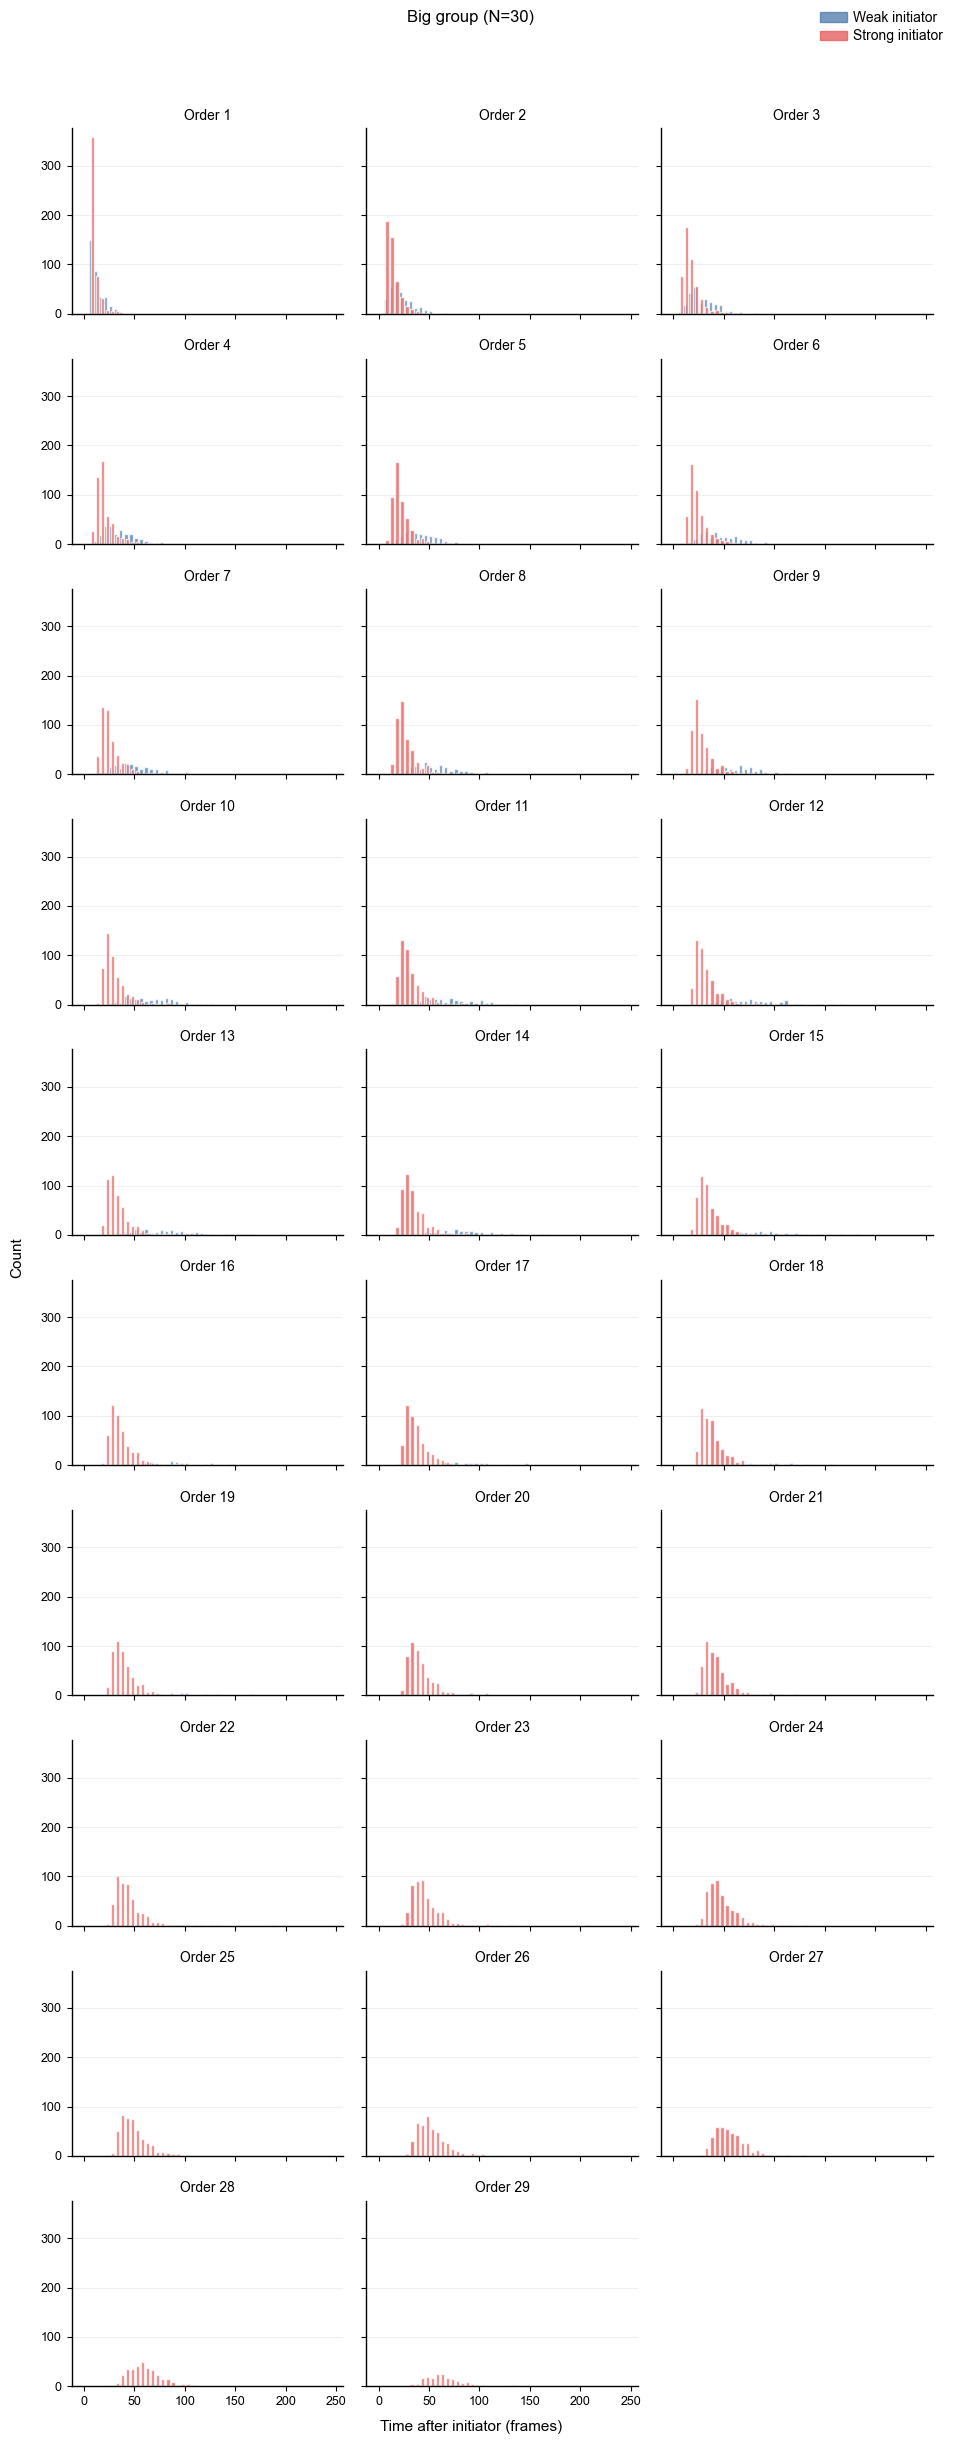

In [52]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------- settings ----------
group_choice = "big"   # "small" or "big"
size_map = {"small": 8, "big": 30}
target_n = size_map[group_choice.lower()]

bin_width = 5
bar_width_factor = 0.65
shift_factor = 0.16

# ---------- data ----------
d = NSD_INPUTS_SUMMARY.copy()
d = d.loc[
    (d["responded"] == True) &
    d["startle_t"].notna() &
    d["order_among_targets"].notna() &
    d["FR_label"].isin(["weak", "strong"]) &
    (d["N"] == target_n)
].copy()

d["startle_t"] = pd.to_numeric(d["startle_t"], errors="coerce")
d["order_among_targets"] = pd.to_numeric(d["order_among_targets"], errors="coerce").astype(int)

orders = sorted(d["order_among_targets"].unique())
if len(orders) == 0:
    raise ValueError("No data after filtering.")

bins = np.arange(0, d["startle_t"].max() + bin_width, bin_width)
centers = (bins[:-1] + bins[1:]) / 2
bar_width = bin_width * bar_width_factor
shift = bin_width * shift_factor

# ---------- one compact multi-panel figure ----------
n = len(orders)
ncols = min(3, n)  # compact grid
nrows = int(np.ceil(n / ncols))

# --- make panels larger + readable ---
panel_w = 3.2   # was ~2.4
panel_h = 2.4   # was ~1.8
title_fs = 10
tick_fs = 9
label_fs = 11
legend_fs = 10

fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(panel_w * ncols, panel_h * nrows),
    sharex=True, sharey=True
)
axes = np.array(axes).reshape(nrows, ncols)

for i, order in enumerate(orders):
    r, c = divmod(i, ncols)
    ax = axes[r, c]

    sub = d[d["order_among_targets"] == order]
    weak_vals = sub.loc[sub["FR_label"] == "weak", "startle_t"].dropna()
    strong_vals = sub.loc[sub["FR_label"] == "strong", "startle_t"].dropna()

    weak_counts, _ = np.histogram(weak_vals, bins=bins)
    strong_counts, _ = np.histogram(strong_vals, bins=bins)

    ax.bar(centers - shift, weak_counts, width=bar_width, alpha=0.75,
           color="#4C78A8", edgecolor="white")
    ax.bar(centers + shift, strong_counts, width=bar_width, alpha=0.75,
           color="#E45756", edgecolor="white")

    ax.set_title(f"Order {order}", fontsize=title_fs)
    ax.tick_params(labelsize=tick_fs)
    ax.grid(axis="y", alpha=0.2)

# remove empty axes
for j in range(n, nrows * ncols):
    r, c = divmod(j, ncols)
    fig.delaxes(axes[r, c])

handles = [
    plt.Rectangle((0, 0), 1, 1, color="#4C78A8", alpha=0.75),
    plt.Rectangle((0, 0), 1, 1, color="#E45756", alpha=0.75),
]
fig.legend(handles, ["Weak initiator", "Strong initiator"],
           loc="upper right", frameon=False, fontsize=legend_fs)

fig.supxlabel("Time after initiator (frames)", fontsize=label_fs)
fig.supylabel("Count", fontsize=label_fs)
fig.suptitle(f"{group_choice.capitalize()} group (N={target_n})", fontsize=12, y=1.02)

plt.tight_layout()
plt.show()



In [53]:
import numpy as np
import pandas as pd
from scipy.stats import mannwhitneyu
import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests

# ---------- choose source ----------
# no speed decay:
src = NSD_INPUTS_SUMMARY.copy()
# with speed decay: src = GMM_INPUTS_SUMMARY.copy()

# ---------- filter ----------
group_n = 8  # big group
d = src.loc[
    (src["N"] == group_n) &
    (src["responded"] == True) &
    src["startle_t"].notna() &
    src["order_among_targets"].notna() &
    src["FR_label"].isin(["weak", "strong"])
].copy()

d["startle_t"] = pd.to_numeric(d["startle_t"], errors="coerce")
d["order"] = pd.to_numeric(d["order_among_targets"], errors="coerce").astype(int)
d["is_strong"] = (d["FR_label"] == "strong").astype(int)

def cliffs_delta(x, y):
    # delta > 0 means x tends to be larger than y
    x = np.asarray(x)
    y = np.asarray(y)
    return (np.sum(x[:, None] > y[None, :]) - np.sum(x[:, None] < y[None, :])) / (len(x) * len(y))

# ---------- per-order tests ----------
rows = []
for o in sorted(d["order"].unique()):
    w = d.loc[(d["order"] == o) & (d["FR_label"] == "weak"), "startle_t"].dropna().values
    s = d.loc[(d["order"] == o) & (d["FR_label"] == "strong"), "startle_t"].dropna().values

    if len(w) < 10 or len(s) < 10:
        rows.append({
            "order": o, "n_weak": len(w), "n_strong": len(s),
            "med_weak": np.nan if len(w)==0 else np.median(w),
            "med_strong": np.nan if len(s)==0 else np.median(s),
            "median_diff_weak_minus_strong": np.nan if (len(w)==0 or len(s)==0) else np.median(w)-np.median(s),
            "cliffs_delta_weak_vs_strong": np.nan, "p": np.nan
        })
        continue

    U, p = mannwhitneyu(w, s, alternative="two-sided")
    delta = cliffs_delta(w, s)  # >0 => weak later than strong
    rows.append({
        "order": o,
        "n_weak": len(w),
        "n_strong": len(s),
        "med_weak": np.median(w),
        "med_strong": np.median(s),
        "median_diff_weak_minus_strong": np.median(w) - np.median(s),
        "cliffs_delta_weak_vs_strong": delta,
        "p": p
    })

res = pd.DataFrame(rows)

# BH-FDR correction
mask = res["p"].notna()
res["p_fdr_bh"] = np.nan
if mask.sum() > 0:
    res.loc[mask, "p_fdr_bh"] = multipletests(res.loc[mask, "p"], method="fdr_bh")[1]

display(res)

# ---------- pooled model (timing among responders) ----------
# log1p stabilizes right tail; strong coefficient < 0 means faster (earlier) strong responders
m = smf.ols("np.log1p(startle_t) ~ is_strong + order", data=d).fit(cov_type="HC3")
print(m.summary().tables[1])


,order,n_weak,n_strong,med_weak,med_strong,median_diff_weak_minus_strong,cliffs_delta_weak_vs_strong,p,p_fdr_bh
0,1,201,388,10.0,8.0,2.0,0.206737,0.000033,0.000082
1,2,114,346,20.0,15.0,5.0,0.276899,0.000009,0.000045
2,3,59,305,28.0,21.0,7.0,0.312253,0.000145,0.000242
3,4,30,277,35.5,29.0,6.5,0.280746,0.011546,0.014432
4,5,11,213,48.0,37.0,11.0,0.266325,0.137125,0.137125
5,6,4,134,38.0,40.0,-2.0,NaN,NaN,NaN
6,7,1,59,49.0,44.0,5.0,NaN,NaN,NaN


                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      2.3714      0.027     87.571      0.000       2.318       2.425
is_strong     -0.1780      0.027     -6.571      0.000      -0.231      -0.125
order          0.2819      0.006     46.777      0.000       0.270       0.294
